In [1]:
import glob
import numpy as np
import awkward as ak
import uproot
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
files = glob.glob("/storage/mxg1065/ttbar_100GB/*.root")

In [3]:
f=uproot.open(files[0])

In [4]:
ttree=f["ntuple;1"]

In [5]:
cell_features=list(filter(lambda x: "Cell" in x, f["ntuple;1"].keys()))
print(cell_features)

['Cell_e', 'Cell_eta', 'Cell_phi', 'Cell_x', 'Cell_y', 'Cell_z', 'Cell_time', 'Cell_ID', 'Cell_layer', 'Cell_quality', 'Cell_provenance', 'Cell_totalNoise', 'Cell_electronicNoise', 'Cell_detName', 'Cell_sampling', 'Cell_badcell', 'Cell_isEM', 'Cell_isEM_Barrel', 'Cell_isEM_EndCap', 'Cell_isFCAL', 'Cell_isHEC', 'Cell_isTile', 'Cell_significance']


In [12]:
ttree["Cell_sampling"].array(library="np")[2]

(20000,)

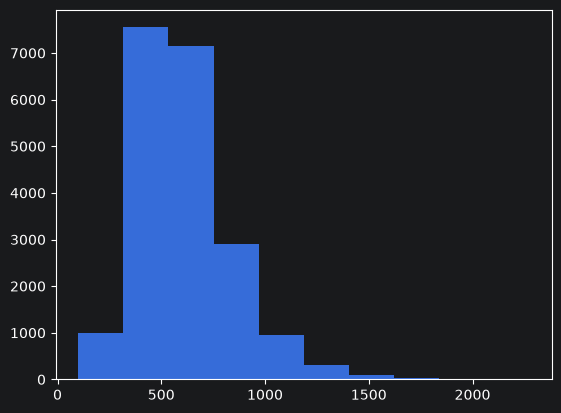

In [15]:
_=plt.hist(list(map(len,ttree["Cell_sampling"].array(library="np"))))

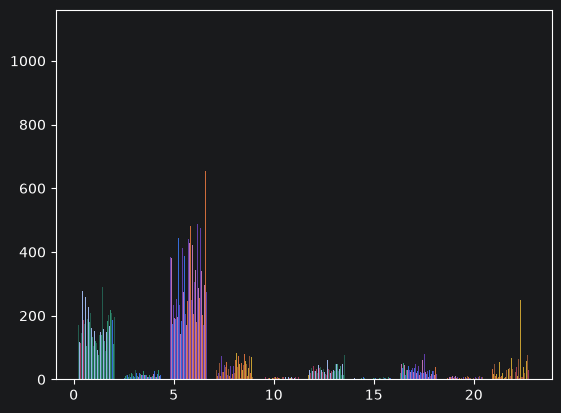

In [16]:
_=plt.hist(ttree["Cell_sampling"].array(library="np").flatten())

In [17]:
f_calo=uproot.open("/storage/mxg1065/input_data/ttbar_100events.root")
tt_calo=f_calo["analysis;1"]

In [50]:
cell_features_calo=list(filter(lambda x: "cell" in x.lower(), f_calo["analysis;1"].keys()))
print(cell_features_calo)

['cell_eta', 'cell_phi', 'cell_x', 'cell_y', 'cell_z', 'cell_subCalo', 'cell_sampling', 'cell_size', 'cell_hashID', 'seedCell_id', 'cell_e', 'cell_noiseSigma', 'cell_SNR', 'cell_time', 'cell_weight', 'cell_truth', 'cell_truth_indices', 'cell_shared_indices', 'cell_cluster_index', 'cluster_to_cell_indices', 'cluster_to_cell_weights', 'cell_to_cluster_e', 'cell_to_cluster_eta', 'cell_to_cluster_phi', 'cellsNo_cluster', 'cellIndices_per_jet']


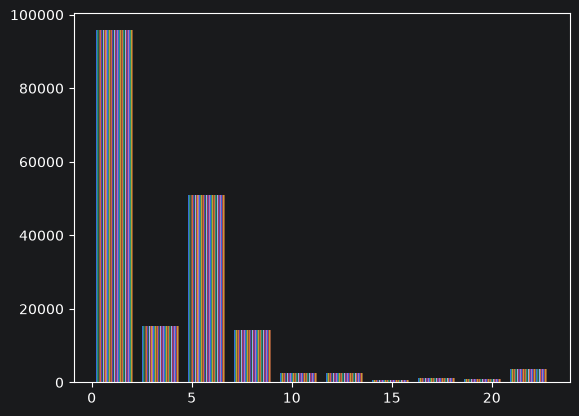

In [18]:
_=plt.hist(tt_calo["cell_sampling"].array(library="np").flatten())


In [33]:
from functools import reduce

cs_calo=list(reduce(lambda x,y: y.extend(x), tt_calo["cell_sampling"].array(library="np").tolist()))
print(cs_calo)
_=plt.hist(cs_calo)

AttributeError: 'numpy.ndarray' object has no attribute 'extend'

In [28]:
cs_calo

[]